In [ ]:
import carla
import pandas as pd
import numpy as np
import cv2
import subprocess
import argparse
import queue
import math
from tqdm import tqdm
from pathlib import Path

def get_actor_blueprints(world):
    bp_lib = world.get_blueprint_library()
    
    # 获取车辆蓝图
    vehicle_bp = bp_lib.find('vehicle.tesla.model3') 
    vehicle_bp.set_attribute('role_name', 'autopilot')
    
    # 获取行人蓝图
    ped_bp = bp_lib.find('walker.pedestrian.0001') 
    ped_bp.set_attribute('role_name', 'pedestrian')
    if ped_bp.has_attribute('is_invincible'):
        ped_bp.set_attribute('is_invincible', 'true')
    
    return vehicle_bp, ped_bp

def preprocess_data(df, src_fps, target_fps):
    """
    数据预处理：插值 + 平滑 + 计算朝向
    """
    print(f"Preprocessing: {src_fps}Hz -> {target_fps}Hz...")
    df['time_sec'] = df['f'] / src_fps
    upsampled_chunks = []
    
    # 按 ID 分组处理
    for agent_id, group in tqdm(df.groupby('id'), desc="Interpolating"):
        group = group.sort_values('time_sec')
        min_time, max_time = group['time_sec'].min(), group['time_sec'].max()
        
        # 生成新的时间轴
        new_index = np.arange(min_time, max_time + 1e-6, 1.0/target_fps)
        
        group_indexed = group.set_index('time_sec')
        # Reindex 并插值
        df_new = group_indexed.reindex(group_indexed.index.union(new_index)).sort_index()
        
        df_new['x'] = df_new['x'].interpolate(method='linear')
        df_new['y'] = df_new['y'].interpolate(method='linear')
        
        # 填充 ID 和 Type
        df_new['id'] = df_new['id'].ffill().bfill()
        df_new['type'] = df_new['type'].ffill().bfill()
        
        # 只保留目标帧率的时间点
        df_new = df_new.loc[new_index]
        
        # --- [修复 1] 计算差分 ---
        # 原代码使用了 fillna(0)，导致最后一帧速度/方向突变为 0
        # 现改为 ffill()，保持最后一帧的状态与前一帧一致
        dx = df_new['x'].diff().shift(-1)
        dy = df_new['y'].diff().shift(-1)
        df_new['dx'] = dx.ffill()
        df_new['dy'] = dy.ffill()
        
        # 计算 Yaw
        yaws = np.degrees(np.arctan2(df_new['dy'], df_new['dx']))
        df_new['yaw'] = yaws
        
        # 计算 Speed
        dt = 1.0 / target_fps
        distances = np.sqrt(df_new['dx']**2 + df_new['dy']**2)
        df_new['speed'] = distances / dt
        
        df_new = df_new.reset_index()
        df_new.rename(columns={'index': 'time_sec'}, inplace=True)
        upsampled_chunks.append(df_new)
        
    df_final = pd.concat(upsampled_chunks)
    
    # 生成新的帧号
    unique_times = sorted(df_final['time_sec'].unique())
    time_to_frame_map = {t: i for i, t in enumerate(unique_times)}
    df_final['new_frame_id'] = df_final['time_sec'].map(time_to_frame_map)
    
    return df_final

def calculate_camera_transform(df, args):
    """
    计算俯视相机位置：确保覆盖所有轨迹
    """
    xmin, xmax = df['x'].min(), df['x'].max()
    ymin, ymax = df['y'].min(), df['y'].max()
    
    center_x = (xmin + xmax) / 2
    center_y = (ymin + ymax) / 2
    
    width_scene_x = xmax - xmin
    height_scene_y = ymax - ymin
    
    aspect_ratio = args.width / args.height
    fov_h_rad = math.radians(args.fov)
    fov_v_rad = 2.0 * math.atan(math.tan(fov_h_rad / 2) / aspect_ratio)
    
    z_for_x = (width_scene_x / 2) / math.tan(fov_h_rad / 2)
    z_for_y = (height_scene_y / 2) / math.tan(fov_v_rad / 2)
    
    z_final = max(z_for_x, z_for_y) * 1.2
    z_final = max(z_final, 20.0) # 最小高度限制
    
    print(f"Bounds: X[{xmin:.1f}, {xmax:.1f}] Y[{ymin:.1f}, {ymax:.1f}]")
    print(f"Camera Height: {z_final:.2f}m")
    
    return carla.Transform(
        carla.Location(x=center_x, y=center_y, z=z_final),
        carla.Rotation(pitch=-90, yaw=-90, roll=0)
    )

def setup_empty_world(client, map_name):
    world = client.get_world()
    if map_name not in world.get_map().name:
        client.load_world(map_name)
        world = client.get_world()

    # 卸载无关图层，加快渲染并减少干扰
    layers_to_unload = [
        carla.MapLayer.Buildings, carla.MapLayer.Decals, carla.MapLayer.Foliage,
        carla.MapLayer.ParkedVehicles, carla.MapLayer.Particles, carla.MapLayer.Props,
        carla.MapLayer.StreetLights, carla.MapLayer.Walls
    ]
    try:
        for layer in layers_to_unload:
            world.unload_map_layer(layer)
    except Exception:
        pass
    return world

def main(args):
    # 1. 读取数据
    df_raw = pd.read_csv(args.trajectory_path)
    df_raw['x'] -= df_raw['x'].mean()
    df_raw['y'] -= df_raw['y'].mean()

    # 2. 连接 CARLA
    client = carla.Client(args.host, args.port)
    client.set_timeout(20.0)
    world = setup_empty_world(client, args.map)
    
    # 3. 预处理
    df_data = preprocess_data(df_raw, args.source_fps, args.target_fps)
    unique_frames = sorted(df_data['new_frame_id'].unique())
    
    # 4. 保存原始设置并应用同步模式
    original_settings = world.get_settings()
    active_actors = {}
    sensor_list = []
    
    try:
        settings = world.get_settings()
        settings.synchronous_mode = True
        settings.fixed_delta_seconds = 1.0 / args.target_fps 
        settings.no_rendering_mode = False 
        world.apply_settings(settings)

        vehicle_bp, ped_bp = get_actor_blueprints(world)

        # 5. 设置相机
        camera_bp = world.get_blueprint_library().find('sensor.camera.rgb')
        camera_bp.set_attribute('image_size_x', str(args.width))
        camera_bp.set_attribute('image_size_y', str(args.height))
        camera_bp.set_attribute('fov', str(args.fov))
        
        camera_transform = calculate_camera_transform(df_data, args)
        camera = world.spawn_actor(camera_bp, camera_transform)
        sensor_list.append(camera)
        
        image_queue = queue.Queue()
        camera.listen(image_queue.put)

        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        video_writer = cv2.VideoWriter(args.output, fourcc, args.target_fps, (args.width, args.height))

        print("Start simulation & recording...")
        
        # 6. 渲染循环
        for frame_idx in tqdm(unique_frames, desc="Rendering"):
            current_data = df_data[df_data['new_frame_id'] == frame_idx]
            current_ids = set(current_data['id'].values)
            active_ids = set(active_actors.keys())

            # A. 销毁 (保持不变)
            to_destroy = active_ids - current_ids
            for agent_id in to_destroy:
                actor = active_actors.pop(agent_id)
                if actor.is_alive: actor.destroy()

            # B. 更新/生成
            for _, row in current_data.iterrows():
                agent_id = int(row['id'])
                agent_type = row['type']
                x, y = row['x'], row['y']
                yaw = row['yaw']
                # 即使是 visualization，也可以保留 speed 用于后续扩展，但这里主要用位置
                
                if np.isnan(yaw): yaw = 0.0
                
                # --- [修改 1] 提高 Z 轴以防止 Z-Fighting (闪烁原因之一) ---
                # 0.1 -> 0.5 避免车辆底盘和路面打架
                z = 0.5 if agent_type == 'vehicle' else 1.15
                
                location = carla.Location(x=x, y=y, z=z)
                rotation = carla.Rotation(pitch=0, yaw=yaw, roll=0)
                final_transform = carla.Transform(location, rotation)

                # ==========================
                #    Actor 控制核心逻辑
                # ==========================
                
                # 1. 尝试生成 (如果不存在)
                if agent_id not in active_actors:
                    bp = vehicle_bp if agent_type == 'vehicle' else ped_bp
                    
                    # --- [修改 2] "高空生成法" 解决闪烁 (核心!) ---
                    # 为了保证生成绝对成功（不被地面的车挡住导致生成失败从而闪烁），
                    # 我们先在天上 100 米处生成它。
                    safe_spawn_transform = carla.Transform(
                        carla.Location(x=x, y=y, z=z + 100.0), 
                        rotation
                    )
                    
                    try:
                        actor = world.try_spawn_actor(bp, safe_spawn_transform)
                        if actor:
                            # --- [修改 3] 彻底关闭物理，解决抖动 ---
                            # 无论是车还是人，全部关闭物理。
                            # 这允许它们相互穿模而不被弹飞。
                            actor.set_simulate_physics(False)
                            
                            # 既然在天上生成的，现在要把它们按下来
                            actor.set_transform(final_transform)
                            
                            active_actors[agent_id] = actor
                        else:
                            # 如果天上都生成不了，那真是没办法了，但这几乎不可能发生
                            pass
                    except Exception as e:
                        print(f"Spawn error: {e}")
                        continue
                
                # 安全检查
                if agent_id not in active_actors:
                    continue

                # 2. 状态更新
                actor = active_actors[agent_id]
                
                # --- [修改 4] 统一使用 set_transform ---
                # 因为物理已经关闭，apply_control 对位置不再起作用。
                # 直接强制设置位置。
                actor.set_transform(final_transform)
                
                # (可选) 如果你想让行人的脚动起来，在 set_simulate_physics(False) 下
                # 通常动画会静止。如果你非常在意脚的动画，需要极其复杂的处理（自定义碰撞通道），
                # 但为了“不抖动”和“不闪现”，静止滑行是目前的最佳权衡。

            # C. 推进一帧
            world.tick()

            # D. 获取图像 (保持不变)
            try:
                image = image_queue.get(timeout=2.0)
                array = np.frombuffer(image.raw_data, dtype=np.dtype("uint8"))
                array = np.reshape(array, (image.height, image.width, 4)) 
                array = array[:, :, :3] 
                video_writer.write(array)
            except queue.Empty:
                print(f"Warning: Frame {frame_idx} dropped (camera timeout)")
                pass

    finally:
        # 7. 清理资源
        if 'video_writer' in locals(): video_writer.release()

        print("Cleaning up actors...")
        for actor in active_actors.values():
            if actor.is_alive: actor.destroy()
            
        print("Cleaning up sensors...")
        for sensor in sensor_list:
            if sensor.is_alive: sensor.destroy()
            
        print("Restoring world settings...")
        world.apply_settings(original_settings)
        print("Done.")

        print(f"Converting {args.output} to VSCode-friendly format...")
        
        try:
            # 执行命令
            tmp_file = Path(args.output).with_suffix('.tmp.mp4')
            subprocess.run([
                'ffmpeg', 
                '-y',  # -y: 覆盖输出文件
                '-i', args.output,    # -i: 输入文件
                '-vcodec', 'libx264',  # -vcodec libx264: 强制使用 H.264 编码器
                '-pix_fmt', 'yuv420p',   # -pix_fmt yuv420p: 【核心】强制使用 YUV420P 像素格式（浏览器兼容必需）
                str(tmp_file)
            ], check=True)
            tmp_file.replace(args.output)
            print(f"Success! Video saved to: {args.output}")
        except subprocess.CalledProcessError as e:
            print("FFmpeg conversion failed. Please ensure ffmpeg is installed.")
        except FileNotFoundError:
            print("Error: 'ffmpeg' command not found. Please install FFmpeg.")


if __name__ == '__main__':
    parser = argparse.ArgumentParser()
    parser.add_argument('--trajectory_path', type=str, required=True, help="Path to CSV file")
    parser.add_argument('--host', type=str, default='127.0.0.1')
    parser.add_argument('--port', type=int, default=3000)
    parser.add_argument('--map', type=str, default='Town05')
    parser.add_argument('--source_fps', type=float, default=2.5, help="Original data FPS")
    parser.add_argument('--target_fps', type=int, default=20, help="Output video FPS")
    parser.add_argument('--output', type=str, default='output.mp4')
    parser.add_argument('--width', type=int, default=1280)
    parser.add_argument('--height', type=int, default=720)
    parser.add_argument('--fov', type=float, default=90.0)
    
    args = parser.parse_args()
    main(args)

正在进行插值: 2.5Hz -> 25Hz ...
Loaded map from data/WayMo/Processed/00874_2_b506cca56fe43ba9/map.png
动画已保存为 trajectory_animation.gif


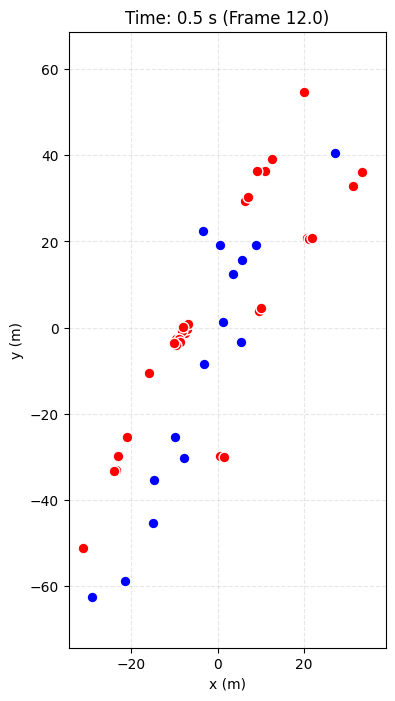

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.animation as animation
from pathlib import Path
from scipy.interpolate import interp1d

# 1. 读取数据
file_path = './logs/app/saved_trajectories/2026-01-04-sim-[UCYDataset]_arxiepiskopi-arxiepiskopi1-from-19.csv.gz'
file_path = './logs/app/saved_trajectories/2026-01-04-sim-[WayMoDataset]_00874_2_b506cca56fe43ba9-from-14.csv.gz'
# 如果是压缩文件，pandas通常能自动推断，或者显式指定 compression='gzip'
df = pd.read_csv(file_path)

# --- 2. 新增：轨迹插值函数 ---
def interpolate_trajectories(df, orig_fps=2.5, target_fps=25):
    print(f"正在进行插值: {orig_fps}Hz -> {target_fps}Hz ...")
    new_rows = []
    
    # 计算插值倍率 (例如 25/2.5 = 10倍)
    ratio = target_fps / orig_fps
    step_size = 1.0 / ratio  # 原始f列的步长假设为1，新的步长就是 0.1
    
    # 对每个 ID 单独插值
    for agent_id, group in df.groupby('id'):
        group = group.sort_values('f')
        if len(group) < 2: continue # 点太少无法插值，跳过
            
        f_orig = group['f'].values
        x_orig = group['x'].values
        y_orig = group['y'].values
        a_type = group['type'].iloc[0]
        
        # 创建插值函数 (linear线性插值)
        # fill_value="extrapolate" 允许少量外推，防止边界丢失，但在轨迹中通常只在范围内插值
        fx = interp1d(f_orig, x_orig, kind='linear')
        fy = interp1d(f_orig, y_orig, kind='linear')
        
        # 生成新的 Frame 序列
        # np.arange(start, stop, step)
        f_new = np.arange(f_orig.min(), f_orig.max(), step_size)
        
        # 补上最后一个点 (arange通常不包含终点)
        if f_new[-1] < f_orig.max():
            f_new = np.append(f_new, f_orig.max())
            
        # 计算新的 x, y
        x_new = fx(f_new)
        y_new = fy(f_new)
        
        # 构建新数据
        for f, x, y in zip(f_new, x_new, y_new):
            new_rows.append({
                'f': round(f, 2), # 保留2位小数，避免浮点精度问题
                'x': x,
                'y': y,
                'id': agent_id,
                'type': a_type
            })
            
    return pd.DataFrame(new_rows)

# === 执行插值 ===
# 注意：原始 f 列假设是整数帧号 (14, 15, 16...)
# 插值后 f 列会变成浮点数 (14.0, 14.1, 14.2...)
df = interpolate_trajectories(df, orig_fps=2.5, target_fps=25)
# =================


# 2. 参数设置
fps = 25
trail_duration = 3.0  # 拖尾时长(秒)
trail_frames = int(trail_duration * fps)  # 换算成帧数 (例如 3*2.5 = 7.5 -> 7)
# 如果希望拖尾更长一点可以 ceil 或 +1
if trail_frames < 1: trail_frames = 1

# 颜色映射
color_map = {
    'pedestrian': 'red', 
    'vehicle': 'blue'
}

# 3. 设置场景范围 (固定视角)
# 留一点边距 (padding)
padding = 1.0
xmin, xmax = df['x'].min() - padding, df['x'].max() + padding
ymin, ymax = df['y'].min() - padding, df['y'].max() + padding

# 2. 加载地图图片
map_path = Path('data/WayMo/Processed/00874_2_b506cca56fe43ba9/map.png')
# 为了演示，如果地图文件不存在，创建一个假的占位图片

if map_path.exists():
    map_img = mpimg.imread(map_path)
    map_extent = (map_path.parent / 'map_range.txt').read_text().strip().split(' ')
    map_extent = tuple(map(float, map_extent))  # 转换为 float 元组
    print(f"Loaded map from {map_path}")
else:
    print(f"Warning: {map_path} not found. Using a placeholder image.")
    # 创建一个灰色的占位图片
    map_img = [[(0.5, 0.5, 0.5) for _ in range(100)] for _ in range(100)]
    map_extent = (xmin, xmax, ymin, ymax)

# 4. 准备画布
fig, ax = plt.subplots(figsize=(10, 8))

# 获取所有唯一的帧号，并排序
unique_frames = sorted(df['f'].unique())

def update(frame_val):
    """
    frame_val: 当前的帧号 (f列的值)
    """
    ax.clear()  # 清除上一帧

    # zorder=0 确保它在最底层，alpha=0.2 设置透明度
    # extent 指定了图片在数据坐标系中的位置 [left, right, bottom, top]
    ax.imshow(map_img, extent=map_extent, alpha=0.2, zorder=0, aspect='auto')

    # 重新设置坐标轴范围 (因为 clear 会重置)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal') # 保持 x, y 比例一致，避免轨迹变形
    ax.set_title(f"Time: {frame_val / fps:.1f} s (Frame {frame_val})")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # 计算拖尾的时间窗口
    start_f = frame_val - trail_frames
    
    # 筛选当前窗口内的数据 (包含拖尾历史和当前位置)
    # 逻辑: start_f <= f <= current_f
    mask = (df['f'] >= start_f) & (df['f'] <= frame_val)
    window_data = df.loc[mask]
    
    if window_data.empty:
        return
        
    # 按 ID 分组绘制
    for agent_id, group in window_data.groupby('id'):
        # 获取该 ID 的类型 (假设同一 ID 类型不变)
        agent_type = group['type'].iloc[0]
        color = color_map.get(agent_type, 'black') # 默认为黑
        
        # 必须按帧排序，保证连线顺序正确
        group = group.sort_values('f')
        
        # --- 绘制拖尾 (线) ---
        ax.plot(group['x'], group['y'], color=color, alpha=0.5, linewidth=2)
        
        # --- 绘制粒子 (当前位置点) ---
        # 只有当该 ID 在"当前帧"有数据时才画点
        current_pos = group[group['f'] == frame_val]
        if not current_pos.empty:
            ax.scatter(current_pos['x'], current_pos['y'], color=color, s=60, edgecolors='white', zorder=5)

# 5. 生成动画
# frames参数传入 unique_frames 列表，这样 update 函数接收到的就是真实的 f 值
ani = animation.FuncAnimation(fig, update, frames=unique_frames, interval=1000/fps)

# 6. 保存或显示
# writer='pillow' 用于保存 gif, 需要安装 pillow 库
ani.save('trajectory_animation.gif', writer='pillow', fps=fps)
print("动画已保存为 trajectory_animation.gif")
# plt.show()

In [8]:
map_extent

(2173.521520996094, 2271.46987121582, -2575.6144287109373, -2407.7539587402343)